# Dissecting racial bias in a medical risk score

---

ML Failures lab: Dissecting Racial Bias in a Medical Risk Score by Nick Merrill, Inderpal Kaur, Samuel Greenberg is licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0).

**Students** can [provide feedback here](https://docs.google.com/forms/d/1jI8oXRkqD1l1ARuZR1y9W_qkOystPr-YEyywNDez46M/edit?ts=5efa772a&dods).

# Background

To effectively manage patients, health systems often need to estimate particular
patients' health risks. Using quantitative measures, or "risk scores,"
healthcare providers can prioritize patients and allocate resources to patients
who need them most.

In this lab, we examine an algorithm widely-used in industry to establish quantitative risk scores for patients. This algorithm uses *medical cost* (i.e., the amount a patient spends on medical care) as a proxy for risk. Through analysis of this data, we will discover how this algorithm embeds a bias against Black patients, undervaluing their medical risk relative to White patients. Crucially, this bias is not immediately visible when comparing medical costs across White and Black pateints.

The key insight of [Obermeyer et al's work](https://science.sciencemag.org/content/366/6464/447) is that bias frequently slips into algorithmic systems unnoticed, particularly when sensitive characteristics (such as race) are ommitted or backgrounded in the data science process. In this case, bias in algorithms affects people's lives very concretely: the bias in the algorithm described here would make it more difficult for Black patients to recieve the care they need.

In this lab, we will learn how to uncover bias in algorithms, using the medical risk score example from Obermeyer et al's paper.

## Agenda

- Investigate relationship between medical cost and risk by race
- Investigate relationship between chronic illness and risk by race
- Investigate interactions between medical cost and chronic illness
- Discussion

In [31]:
# %%capture
# !pip install pandas
# !pip install seaborn
# !pip install statsmodels

In [32]:
%%capture

# import statements
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker
from statsmodels.nonparametric.smoothers_lowess import lowess
%matplotlib inline

## Read in the Data

In [33]:
import requests
from io import StringIO

orig_url="hhttps://drive.google.com/file/d/1lmU8k2C91G2z3f0tRcOl5Y_S_gF8X6Zb/view?usp=drive_link"

file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text
csv_raw = StringIO(url)
data = pd.read_csv(csv_raw)

In [34]:
#utility function
def convert_to_percentile(df, col_name):
    """Convert column to percentile.

    Parameters
    ----------
    df : pd.DataFrame
        Data dataframe.
    col_name : str
        Name of column in df to convert to percentile.

    Returns
    -------
    pd.Series
        Column converted to percentile from 1 to 100

    """
    return pd.qcut(df[col_name].rank(method='first'), 100,
                   labels=range(1, 101))

## Medical cost and risk

To help hospitals and insurance companies identify patients who should qualify for “high-risk care management” programs, the algorithm assigns each patient a risk score. It predicts a patient’s total medical expenditure based on data from insurance claims (age, sex, diagnosis codes, etc.) and uses this variable as a proxy for health care needs.  Patient risk scores are then generated as functions of their predicted expenditures.

If the model is calibrated across race in terms of risk score and expenditure, Black and White patients with a given risk score should have similar total medical expenditures, on average.

To see if this is true, we will generate a graph that shows the mean total medical expenditure by race given a risk score percentile.

First, let's load our medical data. This data represents the estimated risk across patients, along with other details about each patient. You can [grab the data here](https://github.com/daylight-lab/mlfailures/blob/master/health-care-bias-lab.csv). (If you're using this lab as a Jupyter notebook on your computer, place the file in the same directory as your lab. If you're using Google Colab, Click the Files menu in the sidebar and press the upload file button to upload this CSV.)

In [35]:
# add a column of risk percentiles to the dataframe called 'risk_percentile'
risk_percentile = convert_to_percentile(data, "risk_score_t")
data["risk_percentile"] = risk_percentile
data.head()

,risk_score_t,program_enrolled_t,cost_t,cost_avoidable_t,bps_mean_t,ghba1c_mean_t,hct_mean_t,cre_mean_t,ldl_mean_t,race,...,trig_min-normal_tm1,trig_mean-low_tm1,trig_mean-high_tm1,trig_mean-normal_tm1,trig_max-low_tm1,trig_max-high_tm1,trig_max-normal_tm1,gagne_sum_tm1,gagne_sum_t,risk_percentile
0,1.987430,0,1200.0,0.0,NaN,5.4,NaN,1.110000,194.0,white,...,0,0,0,0,0,0,0,0,0,36
1,7.677934,0,2600.0,0.0,119.0,5.5,40.4,0.860000,93.0,white,...,1,0,0,1,0,0,1,4,3,86
2,0.407678,0,500.0,0.0,NaN,NaN,NaN,NaN,NaN,white,...,0,0,0,0,0,0,0,0,0,4
3,0.798369,0,1300.0,0.0,117.0,NaN,NaN,NaN,NaN,white,...,0,0,0,0,0,0,0,0,0,11
4,17.513165,0,1100.0,0.0,116.0,NaN,34.1,1.303333,53.0,white,...,0,0,0,0,0,0,0,1,1,98


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48784 entries, 0 to 48783
Columns: 161 entries, risk_score_t to risk_percentile
dtypes: category(1), float64(22), int64(137), object(1)
memory usage: 59.6+ MB


## Exercise 1
### Medical cost relative to estimated medical risk.

In [37]:
# TODO create dataframe called `group_cost` with the mean total medical expenditure (`cost_t`) for each race (`race`) at each risk percentile (`risk_percentile`)
group_cost = data.groupby(["risk_percentile", "race"])[["cost_t"]].mean().reset_index()
group_cost.head()

/tmp/ipython-input-3452936958.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_cost = data.groupby(["risk_percentile", "race"])[["cost_t"]].mean().reset_index()


,risk_percentile,race,cost_t
0,1,black,1033.333333
1,1,white,905.176471
2,2,black,1365.079365
3,2,white,2959.764706
4,3,black,1271.428571


In [38]:
# TODO Divide `group_cost` into two dataframes based on race
#      Call the two dataframes `b_cost` and `w_cost`.
b_cost = group_cost[group_cost['race'] == 'black']
w_cost = group_cost[group_cost['race'] == 'white']


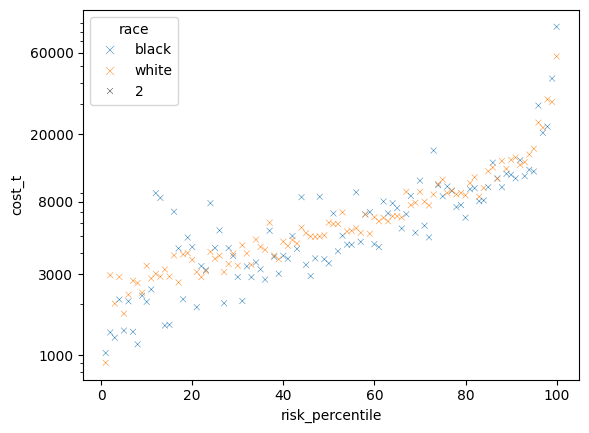

In [39]:
# Plot risk percentile against cost, splitting on race
ax = sns.scatterplot(x = "risk_percentile", y = "cost_t", data = group_cost, hue = "race", marker = "x", size = 2, legend = "full")
plt.yscale('log')
ax.set_yticks([1000, 3000, 8000, 20000, 60000])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
plt.legend;


**QUESTION: What do you notice about the relationship between medical expenditure and risk score by race? Can you conclude from this data that the model is fair or not fair?**
The graph confirms the model is doing exactly what it was trained to do: predict cost. However, because "cost" is a racially biased proxy for "health," the model's accurate cost predictions effectively hide the underlying bias against Black patients' health needs.

**OPTIONAL**: Fit a LOWESS (locally weighted scatterplot smoothing) model to the scatterplot. Or perhaps there's some other model you'd like to try out.

## Chronic illness and risk

Next, we will check to see if the model is calibrated across groups in terms of risk score and chronic illness. In other words: for a given risk score, do Black and white patients have the same "level" of health?

If cost is a good proxy for need, we would expect this graph to be as balanced as the prior graph.  In other words, health care cost should not vary conditional on health between groups.

## Exercise 2
### Examination of chronic illness by race.

In [40]:
# TODO Group the data by `risk_percentile` and `race`.
grouped_by_race = data.groupby(["risk_percentile", "race"])

# TODO Take the mean number of chronic illnesses (`gagne_sum_t`) in each group of race + risk percentile.
#      Call that dataframe `grouped_by_race`
race_chronic_illness = grouped_by_race[["gagne_sum_t"]].mean().reset_index()
race_chronic_illness.head()


/tmp/ipython-input-4201545700.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_by_race = data.groupby(["risk_percentile", "race"])


,risk_percentile,race,gagne_sum_t
0,1,black,0.079365
1,1,white,0.044706
2,2,black,0.206349
3,2,white,0.134118
4,3,black,0.317460


## Exercise 3
### Visualization of chronic illness relative to estimated risk score by race.

<Axes: xlabel='risk_percentile', ylabel='gagne_sum_t'>

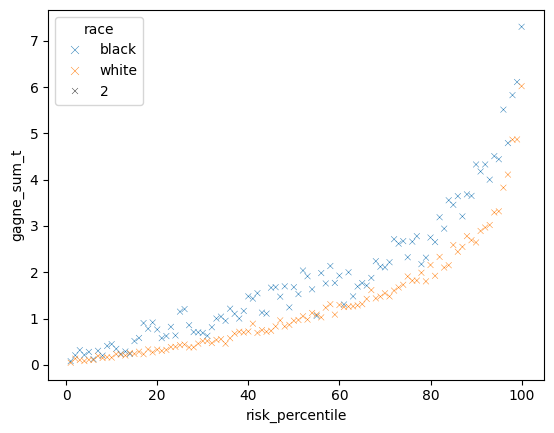

In [41]:
# TODO Plot risk percentile against average number of chronic ilnesses, splitting on race
black_patients = race_chronic_illness[race_chronic_illness['race'] == 'black']
white_patients = race_chronic_illness[race_chronic_illness['race'] == 'white']

sns.scatterplot(x="risk_percentile", y="gagne_sum_t", data=race_chronic_illness, hue="race", marker="x", size=2, legend="full")



**QUESTION: What do you notice about the relationship between chronic illness and risk score by race?  Can you conclude from this data that the model is fair or not fair?**
Based on the visualization, there is a distinct separation between racial groups where, at every risk percentile, Black patients consistently have a significantly higher number of chronic illnesses than White patients. This indicates that the model is unfair because it systematically underestimates the health risks of Black patients; to receive the same risk score and priority for care as White patients, Black patients must be considerably sicker, confirming that the algorithm's reliance on cost as a proxy for health introduces racial bias.

**OPTIONAL**: Fit two generalized linear models, one  the white patients and one to the Black patients. Plot the two models. (Perhaps there's some other type of model you'd like to try as well).

## Interactions between cost and illness

Our work above shows us that a Black patient and a White patient with the same risk score tend to spend the same amount on medical care on average, yet the Black patient tends to have more chronic illnesses.

To understand this interaction, generate a graph that shows the mean total medical expenditure by race, given the number of chronic illnesses.

In [42]:
# add a column of illness percentiles to the dataframe called 'illness_percentile'
illness_percentile = convert_to_percentile(data, "gagne_sum_t")
data['illness_percentile'] = illness_percentile
data.head()

,risk_score_t,program_enrolled_t,cost_t,cost_avoidable_t,bps_mean_t,ghba1c_mean_t,hct_mean_t,cre_mean_t,ldl_mean_t,race,...,trig_mean-low_tm1,trig_mean-high_tm1,trig_mean-normal_tm1,trig_max-low_tm1,trig_max-high_tm1,trig_max-normal_tm1,gagne_sum_tm1,gagne_sum_t,risk_percentile,illness_percentile
0,1.987430,0,1200.0,0.0,NaN,5.4,NaN,1.110000,194.0,white,...,0,0,0,0,0,0,0,0,36,1
1,7.677934,0,2600.0,0.0,119.0,5.5,40.4,0.860000,93.0,white,...,0,0,1,0,0,1,4,3,86,82
2,0.407678,0,500.0,0.0,NaN,NaN,NaN,NaN,NaN,white,...,0,0,0,0,0,0,0,0,4,1
3,0.798369,0,1300.0,0.0,117.0,NaN,NaN,NaN,NaN,white,...,0,0,0,0,0,0,0,0,11,1
4,17.513165,0,1100.0,0.0,116.0,NaN,34.1,1.303333,53.0,white,...,0,0,0,0,0,0,1,1,98,46


## Exercise 4
### Examination of cost relative to illness percentile.

In [44]:
# TODO Group the data by `illness_percentage` and `race`.
#      Take the mean total medical expenditure (`cost_t`) for each group of race + illness percentile.
#      Call the dataframe called `illnesses`

illnesses = data.groupby(["illness_percentile","race"])[["cost_t"]].mean().reset_index()

# TODO divide illnesses into two dataframes based on race: `illness_b` and `illness_w`

illness_b = illnesses[illnesses['race'] == 'black']
illness_w = illnesses[illnesses['race'] == 'white']

illnesses.head()

/tmp/ipython-input-139058082.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  illnesses = data.groupby(["illness_percentile","race"])[["cost_t"]].mean().reset_index()


,illness_percentile,race,cost_t
0,1,black,3825.000000
1,1,white,3883.991228
2,2,black,2955.172414
3,2,white,3705.446623
4,3,black,2985.714286


## Exercise 5
### Visualization of cost relative to level of chronic illness.

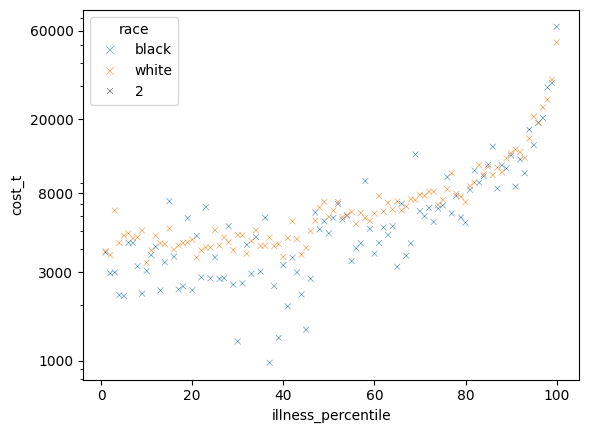

In [45]:
# TODO create a scatterplot of risk percentile against average number of chronic ilnesses, splitting on race
ax = sns.scatterplot(x = "illness_percentile", y = "cost_t", data = illnesses, hue = "race", marker = "x", size = 2, legend = "full")
plt.yscale('log')
ax.set_yticks([1000, 3000, 8000, 20000, 60000])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())


**QUESTION: What can you conclude about the relationship between cost and chronic illness? Why might this relationship exist? What are consequences for the risk score model?**
The data reveals a clear disparity where Black patients consistently generate lower medical costs than White patients at the same level of chronic illness. This gap likely exists due to systemic barriers such as unequal access to care, lack of insurance, or bias in treatment, which result in Black patients utilizing healthcare services less frequently despite having equal medical needs. Consequently, because the algorithm uses medical cost as a proxy for health risk, it misinterprets this lower spending as better health, leading to a biased model that assigns lower risk scores to Black patients and systematically excludes them from necessary care management programs compared to equally sick White patients.

**OPTIONAL**: Fit a LOWESS (locally weighted scatterplot smoothing) model to the scatterplot. Or perhaps there's some other model you'd like to try out.

## Conclusions and takeaways

Even systems that appear balanced across racial groups at first glance may belie underlying biases in the datasets. Thus, seemingly unbiased predictors can in fact be highly correlated with a biasing variable such as race, gender, income or other relational characteristics.

In this example, bias emerged from using an indicator of need (cost) that was itself influenced by race. Biased estimation of need between races resulted.

To better understand the ways in which race influences health care cost, here is a segment from Obermeyer et al’s paper:

>The literature broadly suggests two main potential channels. **First, poor patients face substantial barriers to accessing health care, even when enrolled in insurance plans.** Although the population we study is entirely insured, there are many other mechanisms by which poverty can lead to disparities in use of health care: geography and differential access to transportation, competing demands from jobs or child care, or knowledge of reasons to seek care (1-3). To the extent that race and socioeconomic status are correlated, these factors will differentially affect Black patients. **Second, race could affect costs directly via several channels: direct (“taste-based”) discrimination, changes to the doctor–patient relationship, or others. A recent trial randomly assigned Black patients to a Black or White primary care provider and found significantly higher uptake of recommended preventive care when the provider was Black (4).** This is perhaps the most rigorous demonstration of this effect, and it fits with a larger literature on potential mechanisms by which race can affect health care directly. For example, it has long been documented that Black patients have reduced trust in the health care system (5), a fact that some studies trace to the revelations of the Tuskegee study and other adverse experiences (6). A substantial literature in psychology has documented physicians’ differential perceptions of Black patients, in terms of intelligence, affiliation (7), or pain tolerance (8). **Thus, whether it is communication, trust, or bias, something about the interactions of Black patients with the health care system itself leads to reduced use of health care. The collective effect of these many channels is to lower health spending substantially for Black patients, conditional on need—a finding that has been appreciated for at least two decades (9).**

## Reflection Questions

Here are two final open-ended questions for you to answer.

1. How could we use the data we have to create new proxies for health needs that may be less biased than medical costs?
To reduce racial bias, we can shift the model's target variable from medical cost (cost_t) to physiological health metrics already present in the dataset, such as the Gagne Comorbidity Score (gagne_sum_t) or biometric readings like blood pressure (bps_mean_t) and HbA1c (ghba1c_mean_t). By training the algorithm to predict the number of chronic conditions or specific clinical risks rather than spending, the model would prioritize patients based on actual illness severity, correcting the disparity where Black patients must be significantly sicker to generate the same costs as White patients due to systemic barriers.

2. What are other applications of prediction algorithms where this type of bias may also arise?
This type of proxy bias frequently appears in other high-stakes domains such as credit lending and employment, which are publicly regulated to protect against discrimination. For example, lending algorithms often use zip codes or historical repayment rates as proxies for creditworthiness, which can penalize minority borrowers due to historical redlining, while hiring algorithms using salary history or employment gaps as proxies for aptitude can disadvantage women and minorities affected by wage gaps and caregiving duties, highlighting that ML bias is a sociotechnical problem requiring careful selection of target variables.

## References

1. K. Fiscella, P. Franks, M. R. Gold, C. M. Clancy, JAMA 283, 2579–2584 (2000).
2. N. E. Adler, K. Newman, Health Aff. 21, 60–76 (2002).
3. N. E. Adler, W. T. Boyce, M. A. Chesney, S. Folkman, S. L. Syme, JAMA 269, 3140–3145 (1993).
4. M. Alsan, O. Garrick, G. C. Graziani, “Does diversity matter for health? Experimental evidence from Oakland” (National Bureau of Economic Research, 2018).
5. K. Armstrong, K. L. Ravenell, S. McMurphy, M. Putt, Am. J. Public Health 97, 1283–1289 (2007).
6. M. Alsan, M. Wanamaker, Q. J. Econ. 133, 407–455 (2018).
7. M. van Ryn, J. Burke, Soc. Sci. Med. 50, 813–828 (2000).
8. K. M. Hoffman, S. Trawalter, J. R. Axt, M. N. Oliver, Proc. Natl. Acad. Sci. U.S.A. 113, 4296–4301 (2016).
9. J. J. Escarce, F. W. Puffer, in Racial and Ethnic Differences in the Health of Older Americans (National Academies Press, 1997), chap. 6; www.ncbi.nlm.nih.gov/books/ NBK109841/.

# Feedback

**Instructors**: Please [provide feedback](https://docs.google.com/forms/d/1UuUVBBMTU_2aMvzsGnTR_4i1w3F6tLaaqdIr7dQrgSI/edit?ts=5efa771b&dods) to help improve this lab.

**Students**: Please [provide feedback](https://docs.google.com/forms/d/1jI8oXRkqD1l1ARuZR1y9W_qkOystPr-YEyywNDez46M/edit?ts=5efa772a&dods) to help improve this lab.
